### Homework 4: Forwards and Backwards

## Introduction and Theoretical Explanation

In this assignment we'll be implementing a basic fully-connected feed-forward neural network using NumPy and Pytorch. We will then be using it to classify characters in the MNIST dataset. 

By fully-connected we mean that the output for each unit in the prior layer is given as input for each unit in the following layer.

By feed-forward we mean that the model has a series of layers in which the output of one layer, either fully or partially, is used as input for a subsequent layer, but not any prior layer.

<div style="text-align: center;">
    <img src="nn-diagram.png" alt="fdafdas" width="400"/>
     <p style="text-align: center;">               
        Source: Gow, Stephen & Niranjan, Mahesan & Pearman-Kanza, Samantha & Frey, Jeremy. (2022). 
        A Review of Reinforcement Learning in Chemistry.<em> Digital Discovery. 1.</em> 10.1039/D2DD00047D.
    </p>
</div>

Above is a diagram of a very simple fully-connected feed-forward neural network. Each layer in the diagram is represented by a column of dots, which represent units. 

Mathematically we can think of these networks as a series of composed functions, expressed as:
?
$$ o = \color{#00b446}{f_3(}\color{#4040b8}{f_2(}\color{purple}{f_1(}\color{#f95b00}{x}\color{purple}{)}\color{#4040b8}{)}\color{#00b446}{)} $$

where
- $x$ is the input
- $f_i$ is the $i^{th}$ fully-connected layer
- $o$ is the output of the network

Note that the above diagram has three layers in total, two hidden layers (blue and purple) and an output layer (green). Each layer has multiple units which receive input and send their output to the following layer. Each unit is comprised of two components: a linear function and an activation function. In mathematical notation we could state this as:

$$ o = a(w_1x_1 + w_2x_2 + ... + w_nx_n + b) $$

where
- $o$ is the output of the unit
- $a$ is the activation function, a non-linear function that we discuss more later in the homework
- $w_i$ is the $i^{th}$ weight of the linear function
- $x_i$ is the $i^{th}$ component of the input
- $b$ is the bias term


or rather, expressing the output of the whole layer,

$$ o^{(i)} = a(W^{(i)}x^{(i)} + b^{(i)}) $$
where 
- $o^{(i)}$ is the output of the layer, a one dimensional vector with the same length as the number of units in the layer
- $x^{(i)}$ is the input into the $i^{th}$ layer, which is often equal to the output of the previous layer $o^{(i-1)}$
- $W^{(i)}$ is a matrix with dimensions (num_units, input_size) that holds the weights of all linear units in the layer
- $b^{(i)}$ is the bias term which is a one dimensional vector with the same length as the number of units in the layer

Let's combine these formulations to express the above network in terms of **functional composition**. The components of a given layer are shown in the same color.

$$
o = \color{#00b446}a^{(3)}(W^{(3)}\color{#4040b8}a^{(2)}(W^{(2)}\color{purple}a^{(1)}(W^{(1)}(\color{#f95b00}x\color{purple}) + b^{(1)})\color{#4040b8} + b^{(2)}) \color{#00b446} + b^{(3)})
$$

From this you should have an idea of how an input is evaluated by this kind of neural network. In this homework we start by writing classes for each of the network's components and then combining them at the end with in a `Model` class. Each of the classes we'll be implementing today will have a `forward` method which will do the portion of the above computation for the respective component.

We will also implement a `backwards` method which is used during training and will compute the gradient of `forward` as a part of a larger gradient computation.

To make a network useful and accurately classifying inputs we have to adjust and tune all of the weights and biases in each unit. To do this we'll use a method called stochastic gradient descent (SGD) with mini-batches. This technique uses a loss function, often denoted with $\mathcal{L}$, which measures how 'wrong' the network is. The goal of training is to adjust and tune the weights and biases of the network such that $\mathcal{L}$ is minimized. To this end we calculate the gradient of $\mathcal{L}$ with respect to some single weight or bias, which tells us which way we should adjust a parameter to reduce the value of $\mathcal{L}$. In mathematical notation, where $z$ is the output of a linear function, or rather the pre-activation value of the unit. 

$$ \frac{\partial\mathcal{L}}{\partial w} = \frac{\partial\mathcal{L}}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial w} \;\;\; \text{or} \;\;\; \frac{\partial\mathcal{L}}{\partial b} = \frac{\partial\mathcal{L}}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial b}$$


To calculate the gradient of the weights we'll utilize the chain rule of derivation:

$$ \frac{d}{dx}f(g(h(x))) = f'(g(x))) \cdot g'(x)$$

and when calculating the gradient of the activation function we'll use the additive rule of derivation as well:

$$ \frac{d}{dx}(f(x) + g(x)) = f'(x) + g'(x)$$

Note from the above rules that we will need to be able to calculate the first derivative of every component with respect to one of the inputs. Practically, our implementation will calculate the derivative for every input in parallel, or rather the gradient, which is what `backwards` does.

Training a network is an iterative process where we find the network's current outputs on some labeled data samples (`forward`), find the gradients of each parameter (`backward`), and adjust each parameter so the value of the loss function decreases for said inputs (`update_parameters`), usually until the values of the loss function stabilize at a minimum. 

In [1]:
import numpy as np
from typing import Any, List, Optional

## Linear class

The linear layer contains multiple linear units. Within a network a linear layer will have an input size equal the output size of the previous layer, and an output size equal to the number of linear units within the layer. 

Below you will implement the `__init__`, `forward`, `backward`, and `update_parameters` methods of the layer. Assume that the input shape to `forward` or `backward` will be of `(num_samples, input_size)` .

`__init__(self, input_dim: int, output_dim: int) -> None:`

The layer should contain the following attributes at minimum:

- A two dimensional numpy array that contains the weights of all linear units in the layer. The initial values of these weights should be initialized to random values from a Gaussian distribution with $\mu = 0$ and $\sigma = \sqrt{\frac{2}{\mathrm{input\_size}}}$. This initialization method is known as He initialization.
- A one dimensional numpy array that contains the biases for each linear unit which are initialized to zero.
- _Optional Parameters_: To increase readability we should still declare attributes that will be used to store intermediate data required for each method but are not set in the `__init__` method. Set these to `None`. This would include the gradients of the weights, the gradients of the biases, and the previous input.

`forward(self, x: np.ndarray) -> np.ndarray:`

- **Input:** Some ndarray of shape `(num_samples, input_dim)`
- Save the passed input to an internal attribute, as this is required when calculating the gradient in `backward`. 
- **Returns:** The linear transformation of passed inputs. 

The output of the $j^{\text{th}}$ linear unit for one input $x$ is defined as:
$$
z_j = w_{1j}x_1 + w_{2j}x_2 + ... + w_{nj}x_n + b_j
$$
Note that for an input of size `(num_samples, input_dim)` a calculation of this kind will be done `num_samples * output_dim` times for a given call to forward.

`backward(self, grad_output: np.ndarray) -> np.ndarray:`

- **Input:** gradient of the loss function with respect to every output value of its own units from the previous call to `forward`. 
- Calculate and internally save the gradient of the loss function with respect to each weight and bias in the layer.
- **Returns:** the gradient of the loss function with respect to its own inputs. 

Below are the gradient calculations for individual weight, bias, and input values, where $i$ is the weight index within a linear unit, $j$ is the index of the unit within the layer, and $k$ is the index of a sample within the input.

$$
\frac{\partial \mathcal{L}}{\partial w_{ij}} = \frac{\partial \mathcal{L}}{\partial z_j} \cdot \frac{\partial z_j}{\partial w_{ij}} = \frac{\partial \mathcal{L}}{\partial z_j} * x_i \;\; \text{or} \;\; \sum_k  \frac{\partial \mathcal{L}}{\partial z_{jk}} * x_{ik} 
$$

$$
\frac{\partial \mathcal{L}}{\partial b_j} = \frac{\partial \mathcal{L}}{\partial z_j} \cdot \frac{\partial z_j}{\partial b_j} = \frac{\partial \mathcal{L}}{\partial z_j} \;\; \text{or} \;\; \sum_k \frac{\partial \mathcal{L}}{\partial z_{jk}}
$$

$$
\frac{\partial \mathcal{L}}{\partial x_{ik}} = \sum_j \frac{\partial \mathcal{L}}{\partial z_j} \cdot \frac{\partial z_j}{\partial x_{ik}} = \sum_j \frac{\partial \mathcal{L}}{\partial z_j} * w_{ij} 
$$

All of this can be done via matrix multiplications.

`update_params(self, learning_rate: float) -> None:`

Updates the weights and biases of the network. The formula for this is as follows, where $\eta$ is the `learning_rate`:
$$
\begin{align*}
w_{ij} \leftarrow w_{ij} - \eta \frac{\partial \mathcal{L}}{\partial w_{ij}}
&\;\;\;\text{and}\;\;\;&
b_{j} \leftarrow b_{j} - \eta \frac{\partial \mathcal{L}}{\partial b_{j}}
\end{align*}
$$
where $\eta$ is the learning rate.


##### Tips, Hints, and Sanity Checks 
- Your gradient calculations during `backwards` should be the same `shape` as the attribute it is in respect to (e.g. `_grad_weights.shape == weights.shape`).
- Consider the desired `shape` of any attribute you are calculating. Considering the shapes of other attributes and how `@` and `+` operations transform shape, how could we create a value with the desired shape?

In [2]:
import numpy as np

class Linear:
    """Implements a linear (fully connected) layer."""

    def __init__(self, input_dim: int, output_dim: int) -> None:
        # Initialization: Scale weights to keep signal variance stable
        # std is a scalar
        std = np.sqrt(2.0 / input_dim)
        
        # weights shape: (output_dim, input_dim)
        self.weights = np.random.normal(0, std, (output_dim, input_dim))
        
        # biases shape: (output_dim,)
        self.biases = np.zeros(output_dim)
        
        # Placeholders for data needed during backward pass and updates
        self.x = None            # Input: (batch_size, input_dim)
        self.grad_weights = None # Gradient wrt weights: (output_dim, input_dim)
        self.grad_biases = None  # Gradient wrt biases: (output_dim,)

    def __call__(self, x: np.ndarray) -> np.ndarray:
        return self.forward(x)

    def forward(self, x: np.ndarray) -> np.ndarray:
        """
        Forward pass: Compute z = xW^T + b
        In:  x shape: (batch_size, input_dim)
        Out: z shape: (batch_size, output_dim)
        """
        # Save input for the chain rule calculation in backward()
        self.x = x

        # Matrix multiplication: (batch_size, input_dim) @ (input_dim, output_dim)
        # Note: self.weights.T flips (output_dim, input_dim) to (input_dim, output_dim)
        # Resulting shape: (batch_size, output_dim)
        return x @ self.weights.T + self.biases

    def backward(self, grad_output: np.ndarray) -> np.ndarray:
        """
        Backward pass: Calculate gradients using the chain rule.
        In:  grad_output shape: (batch_size, output_dim)
        Out: grad_input shape:  (batch_size, input_dim)
        """
        # 1. Gradient wrt Weights: dL/dW = grad_output^T @ x
        # (output_dim, batch_size) @ (batch_size, input_dim) -> (output_dim, input_dim)
        self.grad_weights = grad_output.T @ self.x
        
        # 2. Gradient wrt Biases: Sum gradients across the batch
        # Summing (batch_size, output_dim) along axis 0 -> (output_dim,)
        self.grad_biases = np.sum(grad_output, axis=0)
        
        # 3. Gradient wrt Input: dL/dx = grad_output @ W
        # (batch_size, output_dim) @ (output_dim, input_dim) -> (batch_size, input_dim)
        # This is returned to the previous layer in the network
        grad_input = grad_output @ self.weights
        
        return grad_input

    def update_params(self, learning_rate: float) -> None:
        """
        Gradient Descent update: Move parameters in the opposite direction of the gradient.
        weights/biases shape remain unchanged.
        """
        # New_Weight = Old_Weight - (learning_rate * Gradient)
        self.weights -= learning_rate * self.grad_weights
        self.biases -= learning_rate * self.grad_biases

## Activation function: ReLU

Between each layer of a neural network you'll find a non-linear function. This is the key feature that allows a neural network to approximate non-linear functions. If we were to not have a non-linear function between layers, we'd have a linear model, and all multi-layer linear models can be reduced to a single linear calculation (I'll leave the proof as a fun exercise that has no applicability to the course). 

A rectified linear unit (ReLU) is a common non-linear function found in neural networks. In this context, the non-linear function is also called a non-linearity or an activation function. Other activation functions include hyperbolic tangent, sigmoid, and exponential linear unit, among many others, but they are all out of scope for this exercise.

In the below class we'll be implementing the forward and backward passes of the ReLU function. 


`__init__(self) -> None:`

- ReLU itself doesn't contain any trainable parameters, however, we will still need to save the gradient of the output during `forward`.


`forward(self, x: np.ndarray) -> np.ndarray:`

- **Input:** array of shape `(num_samples, input_dim)` 
- **Returns:** The input with the ReLU function, $a^{(i)} = \mathrm{ReLU}(x) = \mathrm{max}(0, x)$, applied in an element-wise fashion.

`backward(self, grad_output: np.ndarray) -> np.ndarray:`

- **Input:** gradient of the cost function with respect to every output value of its own units from the previous call to `forward`.
- **Return:** The gradient of the cost function with respect to each input, as defined below.

The partial derivative of the ReLU function is below, setting the derivative at $x = 0$ to $0$:

$$
\frac{\partial \mathrm{ReLU(x)}}{\partial x} = 
\begin{cases}
    1 & \text{if } x > 0, \\
    0 & \text{if } x \leq 0
\end{cases}
$$

Below is the derivation of the cost function with respect to the input:

$$
\frac{\partial \mathcal{L}}{\partial z_i} = \frac{\partial \mathcal{L}}{\partial a_i} \cdot \frac{\partial a_i}{\partial z_i}
$$

In [3]:
class ReLU:

    def __init__(self) -> None:
        self._input: Optional[np.ndarray] = None

    def __call__(self, x: np.ndarray) -> np.ndarray:
        return self.forward(x)

### Please enter your solution here ###

    def forward(self, x: np.ndarray) -> np.ndarray:
        # Save the input for use in the backward pass
        self._input = x
        # Return max(0, x) element-wise
        return np.maximum(0, x)

    def backward(self, grad_output: np.ndarray) -> np.ndarray:
        # The gradient is 1 where input > 0, and 0 otherwise.
        # We multiply this element-wise by the incoming gradient (chain rule).
        grad_input = grad_output.copy()
        grad_input[self._input <= 0] = 0
        return grad_input

### Please enter your solution here ###



## Loss function: Cross Entropy

The loss function is a measure of how far off the results of the network are from the actual results. The particular function that is used is often dependent on the application and type of prediction being made. When we're trying to predict some real-valued number, we would often use average mean squared error. For categorical data, which is what is found in the MNIST dataset, we'll use a cross entropy loss.

#### Categorical encoding

First though, we need to consider how we'll represent this categorical information. It's often the case when working with processed training data that different categories will be represented by a number, which can be thought of as the index of some list of categorical labels. This is what the MNIST dataset provides, however, given that the labels of the MNIST dataset are those of handwritten digits, we have the convenient and _coincidental_ benefit that the index for each category has a very literal relationship to the category label. 

Categorical models will often output a discrete probability distribution over all categories, literally a list of numbers, summing to one, and one for each category, predicting the likelihood that the input is a member of a particular category. Given this output from our model, we must also convert our labels to this format. Since we assume the labels of our training data to be correct with $p=1.0$ each label will be a list with a single `1` in the index of the correct category. This is often called **one-hot encoding**. For example, for the category at index 3, which in our case is _coincidentally_ the digit "3", we have:

`3 = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`

The above list is of length 10 because we are classifying into 10 different categories.

#### Softmax

One problem we have is that the raw output of the network, called logits and denoted by $\hat y$, almost never sums to 1 and the values will likely not all be in $[0,1]$, as is a requirement for a probability distribution. We can, however, force this property by normalizing the output. To do this we'll apply a **softmax** function to $\hat y$. The $i^{th}$ entry the distribution $q$, which is $\hat y$ with softmax applied is:

$$
q_i = \frac{e^{\hat y_i}}{\sum_{j} e^{\hat y_j}} 
= \frac{e^{-\max_{j} \hat y_j}}{e^{-\max_{j} \hat y_j}} \cdot \frac{e^{\hat y_i}}{\sum_{j} e^{\hat y_j}} 
= \frac{e^{\hat y_i - \max_{j} \hat y_j}}{\sum_{k} e^{\hat y_k - \max_{j} \hat y_j}} 
$$

For numerical stability we will multiply both the numerator and denominator by $e^{\hat y_j}$. This is due to the potential for exponents of large numbers to overflow into `inf`, which would break the training.

Since $e^x$ is monotonically increasing, or rather only increases as $x$ increases, we still have the same relative ordering of entries in the output, although the relative difference between the entries has changed. This relative ordering is important, as during inference we can still find the most likely category by using the largest value in the output without applying the softmax. 

#### Cross-entropy

The loss function $\mathcal{L}(p, q)$ we'll be using is called **Cross-entropy Loss**. Cross-entropy $H(p, q)$ measures the difference between two probability distributions and is expressed as such:

$$
H(p, q) = -\sum^{K}_{k=1} p_k \log( q_k)
$$

where 
- $p$ is the true label with $p_k$ being the $k^{th}$ element of $p$.
- $q$ is the network output with the softmax applied, with $q_k$ being the $k^{th}$ element of $q$.
- And $K$ is the number of elements in $p$ and $q$

And the loss is the average cross-entropy across $N$ samples:

$$
\mathcal{L}(P, Q) = -\frac{1}{N}\sum^{N}_{n=1}\sum^{K}_{k=1} p_{n,k} \log( q_{n,k})
$$

where
- $N$ is the number of samples being calculated in the loss function.
- $P$ is the true distribution for a list of samples.
- $Q$ is the network's predicted distributions for the samples corresponding to $P$.
- $p_{n,k}$ is the $k^{th}$ element of the $n^{th}$ sample label in $P$.
- $q_{n,k}$ is the $k^{th}$ element of the $n^{th}$ network output with softmax in $Q$.



#### Calculating the gradients of the loss

For training we must calculate the gradient of $\mathcal{L}(p, q)$ with respect to the network's outputs, or in mathematical notation:

$$
\frac{\partial \mathcal{L}}{\partial \hat y_i} = \frac{\partial \mathcal{L}}{\partial q_i} \cdot \frac{\partial q_i}{\partial \hat y_i} + \sum_{i \neq j} \frac{\partial \mathcal{L}}{\partial q_i} \cdot \frac{\partial q_i}{\partial \hat y_j}
$$

The partial derivative of $\mathcal{L}$ with respect to a single softmax value $q_i$, and the partial derivative of the softmax entry $q_i$ with respect to the network output for that entry $\hat y_i$ are stated below:


$$
\begin{align*}
\frac{\partial \mathcal{L}}{\partial q_i} =
\begin{cases}
    -\frac{1}{N} \cdot \frac{1}{q_i} & \text{if } i = y \\
    0 & \text{if } i \neq y
\end{cases}
& \; \; \; \; \; &
\frac{\partial q_i}{\partial \hat y_j} =
\begin{cases}
    q_i(1-q_i) & \text{if } i = j \\
    -q_i q_j & \text{if } i \neq j
\end{cases}
\end{align*}
$$



Putting these together we'll consider the cases of the logit with the correct class ($i = y$) and the logits of the incorrect classes ($i \neq y$).

$$
\frac{\partial \mathcal{L}}{\partial \hat y_i} = 
\begin{cases}
    -\frac{1}{N} \cdot \frac{1}{q_y} \cdot q_y(1 - q_y) = -\frac{1 - q_y}{N} = \frac{q_y - 1}{N} & \text{if } i = y \\
    -\frac{1}{N} \cdot \frac{1}{q_y} \cdot (-q_i q_y) = -\frac{q_i}{N} & \text{if } i \neq y
\end{cases}
$$

Considering what we know about one hot encoding, we can generalize this to: 

$$
\frac{\partial \mathcal{L}}{\partial \hat y_i} = \frac{1}{N} (q_i - p_i)
$$

#### Writing the `CrossEntropy` Class

`__init__(self) -> None`

- Declare optional attributes which will be set in `forward` and `backward`

`forward(self, logits: np.ndarray, labels: np.ndarray) -> float`

- **Input:**
    - `logits` -- The raw network output, before softmax is applied
    - `labels` -- The index of the true label 
- Save the predicted probabilities and labels for `backward`.
- Be sure to apply softmax to the input.
- **Return:** Value of the loss function.

`backward(self) -> np.ndarray`
- **Input:** Nothing
- You will probably have to make a copy of your stored predicted probabilities.
- **Return:** Partial derivative of the loss function with regard to every input into the loss.

In [4]:
class CrossEntropy:
    def __init__(self) -> None:
        # Predicted probabilities (after softmax)
        self.probs = None
        # True labels (as a one-hot encoded matrix or indices)
        self.labels = None
        # Number of samples in the current batch
        self.n_samples = None

    def __call__(self, logits: np.ndarray, labels: np.ndarray) -> float:
        return self.forward(logits, labels)

    def forward(self, logits: np.ndarray, labels: np.ndarray) -> float:
        """
        Calculates Softmax and then Cross-Entropy Loss.
        logits: (batch_size, num_classes) - raw output from Linear layer
        labels: (batch_size,) - integer indices of the correct classes
        """
        self.n_samples = logits.shape[0]
        
        # 1. Numerically Stable Softmax
        # Subtract max(logits) from each row to prevent exp(large_number) overflow
        shift_logits = logits - np.max(logits, axis=1, keepdims=True)
        exps = np.exp(shift_logits)
        self.probs = exps / np.sum(exps, axis=1, keepdims=True) # (batch_size, num_classes)
        
        # Save labels for backward pass
        self.labels = labels
        
        # 2. Calculate Cross-Entropy Loss
        # We only care about the probability assigned to the CORRECT class
        # np.arange(n) helps select the correct row, 'labels' selects the correct column
        correct_log_probs = -np.log(self.probs[np.arange(self.n_samples), labels] + 1e-12) # added epsilon for stability
        
        # Return average loss across the batch
        return np.sum(correct_log_probs) / self.n_samples

    def backward(self) -> np.ndarray:
        """
        Returns the gradient of the loss with respect to the logits.
        Formula: (Probabilities - One_Hot_Labels) / N
        """
        # Create a copy of probabilities to modify
        grad = self.probs.copy()
        
        # Subtract 1 from the probability of the correct class (the 'p_i' part of the formula)
        # This effectively implements (q_i - p_i) where p_i is 1 for the correct class and 0 otherwise
        grad[np.arange(self.n_samples), self.labels] -= 1
        
        # Divide by the number of samples to get the average gradient
        return grad / self.n_samples

## Model class

The `Model` class integrates all of the classes we have written so far together, taking a list of layers and moving outputs forward and gradients backwards.

<br />

`__init__(self, input_dim: int, output_dim: int, layer_size: List[int]) -> None:`
- **Input:** 
  - `input_dim` -- The size of the input of the network
  - `output_dim` -- The size of the output of the network (10 in for MNIST)
  - `layer_size` -- The sizes of each hidden layer in the order they appear, with the shape at index 0 accepting the network input.
- Instantiate the network as alternating layers of `Linear` and `ReLU` classes such that every hidden `Linear` object is followed by a`ReLU` with the exception of the very last hidden layer.  
- **Return:** None

<br />

`forward(self, input: np.ndarray) -> np.ndarray`
- **Input:** Some input to the network of shape `(num_samples, data_size)`.
- Use the `forward` method of each component to pass `input` through all network components in sequential order.
- Simple python structures recommended. 
- **Return:** The logits (no softmax applied) for each sample in the input.

<br />

`backward(self, grad_output: np.ndarray) -> None`
- **Input:** The gradient of the loss function with respect to the network output, or rather the logits.
- Use the `backward` method of each component to pass the gradient in reverse order. 
- Pass the gradient back through the components of the network, starting from the last layer and going to the input layer.
- **Return:** None


Implement the `backward` method, which takes the gradient of the loss function and use it as input for the `backward` method of the last layer. Any given output of a `backward` method is used as input for the `backward` method of the previous layer. Continue this until there is no previous layer.

<br />

`update_params(self) -> None`
- Calls the `update_params` method of all components that possess it.

<br />


In [5]:
class Model:
    def __init__(self, input_dim: int, output_dim: int, network_shape: List[int]) -> None:
        """
        Initializes the network architecture.
        Structure: Linear -> ReLU -> Linear -> ReLU -> ... -> Linear (Output)
        """
        self.layers = []
        
        # 1. Build Hidden Layers
        current_dim = input_dim
        for h_dim in network_shape:
            self.layers.append(Linear(current_dim, h_dim))
            self.layers.append(ReLU())
            current_dim = h_dim
        
        # 2. Build Output Layer
        # The last layer is strictly Linear (no ReLU) to produce raw logits
        self.layers.append(Linear(current_dim, output_dim))

    def __call__(self, x: np.ndarray) -> np.ndarray:
        return self.forward(x)

    def forward(self, x: np.ndarray) -> np.ndarray:
        """
        Passes input through all layers in sequential order.
        In:  x shape (batch_size, input_dim)
        Out: logits shape (batch_size, output_dim)
        """
        activation = x
        for layer in self.layers:
            activation = layer.forward(activation)
        
        return activation

    def backward(self, grad_output: np.ndarray) -> None:
        """
        Propagates the gradient of the loss back through the network in reverse.
        In: grad_output (gradient of loss wrt logits) from CrossEntropy.backward()
        """
        # Start with the gradient from the loss function
        gradient = grad_output
        
        # Iterate through layers in reverse order (Last Layer -> First Layer)
        for layer in reversed(self.layers):
            gradient = layer.backward(gradient)

    def update_params(self, learning_rate: float) -> None:
        """
        Triggers parameter updates for all layers that have trainable parameters (Linear).
        ReLU layers do not have an update_params method, so we check for existence.
        """
        for layer in self.layers:
            # Check if the layer has the update_params method (Linear vs ReLU)
            if hasattr(layer, 'update_params'):
                layer.update_params(learning_rate)

## Training: Mini-Batch Stochastic Gradient Descent


```
train_ffnn(
    network_shape: list[int], loss_fn: CrossEntropy,
    X_train: np.ndarray, y_train: np.ndarray,
    X_val: np.ndarray, y_val: np.ndarray,
    batch_size: int, num_epochs: int, learning_rate: float) -> Model, dict: 
```

- **Input:**
  -  `network_shape` -- A list of integers stating the number of units in each hidden layer. 
  - `loss_fn` -- Loss function used during training
  - `X_train, y_train`, `X_val`, `y_val` -- Samples (`X`) and labels (`y`) of the training and validation data
  - `batch_size` -- The number of samples per update
  - `num_epochs` -- The number of iterations through our training set
  - `learning_rate` -- Regulates the amount we change our trainable parameters per update
- **Return:**
  - `model` -- The trained model
  - `log_dict` -- Accuracy and loss records for every epoch


Training a network involves taking a randomly initialized model and fitting it to a dataset using an iterative optimization process. These iterations roughly have the following steps:

1. Sample points from a dataset (`X_train` and `y_train`) 
2. Measure the difference between `model(X_train_sample)` and `y_train_sample` using some loss function (`loss_fn`)
3. Find how much to change the model's parameters (`backward`) and update (`update_params`). 
4. Collect statistics on the model.

In our training function we'll make the following decisions:
- Sampling from the dataset with **mini-batches**, which randomly selects `batch_size` samples from the dataset without replacement until the dataset is exhausted.
  - This can be done by using an array of sample indices (`np.arange(X_train.shape[0])`) and shuffling them before every epoch.
- Using SGD to update our model's parameters. This is implemented in the `Model` class.
- Collecting average loss and accuracy for every epoch for both the `train` and `val` datasets. 
  - For accuracy, we will consider an output correct if the index of the label has the highest value, and incorrect otherwise.
  - Recall that the loss function returns the average loss for a sample in the batch. When aggregating the loss from the train and val sets, this needs to be accounted for.
  - Get the loss and accuracy of the validation set for an epoch after updating the model with the training set.
- Every time we exhaust the training dataset, called an epoch, we will log the loss and accuracy for both datasets.
  - Use the keys `"train_loss"`, `"train_acc"`, `"val_loss"`, and `"val_acc"`. 

In [6]:
def train_ffnn(
        network_shape: list[int], loss_fn: CrossEntropy,
        X_train: np.ndarray, y_train: np.ndarray,
        X_val: np.ndarray, y_val: np.ndarray,
        batch_size: int, num_epochs: int, learning_rate: float) -> tuple:

    num_samples: int = X_train.shape[0]
    input_dim = X_train.shape[1]
    # For MNIST, output_dim is usually 10
    output_dim = 10 
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    # 1. Instantiate the model
    model = Model(input_dim, output_dim, network_shape)

    for epoch in range(num_epochs):
        # 2. Shuffle the training data indices at the start of each epoch
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        
        # Track total loss and correct predictions for the epoch
        total_epoch_loss = 0
        total_correct_train = 0

        # 3. Mini-batch Training Loop
        for start_idx in range(0, num_samples, batch_size):
            end_idx = min(start_idx + batch_size, num_samples)
            batch_indices = indices[start_idx:end_idx]
            
            # Select samples for the current batch
            x_batch = X_train[batch_indices] # shape: (batch_size, input_dim)
            y_batch = y_train[batch_indices] # shape: (batch_size,)

            # Forward pass: get raw scores (logits)
            logits = model.forward(x_batch)
            
            # Compute loss: average loss for the samples in this batch
            batch_loss = loss_fn.forward(logits, y_batch)
            # Accumulate total loss (multiply by current batch size to de-average)
            total_epoch_loss += batch_loss * (end_idx - start_idx)
            
            # Compute training accuracy: index of highest logit is the prediction
            predictions = np.argmax(logits, axis=1)
            total_correct_train += np.sum(predictions == y_batch)
            
            # Backward pass: get gradient from loss function
            grad_output = loss_fn.backward()
            model.backward(grad_output)
            
            # Update parameters using SGD
            model.update_params(learning_rate)

        # Compute average training metrics
        avg_train_loss = total_epoch_loss / num_samples
        train_accuracy = total_correct_train / num_samples

        # 4. Validation Pass (No parameter updates here!)
        val_logits = model.forward(X_val)
        # Compute loss on validation set
        val_loss = loss_fn.forward(val_logits, y_val)
        # Compute validation accuracy
        val_preds = np.argmax(val_logits, axis=1)
        val_accuracy = np.sum(val_preds == y_val) / X_val.shape[0]

        # Record history
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_accuracy)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_accuracy)

        print(f"Epoch {epoch + 1}/{num_epochs}, "
            f"Train Loss: {avg_train_loss:.6f}, Train Acc: {train_accuracy * 100:.2f}%, "
            f"Val Loss: {val_loss:.6f}, Val Acc: {val_accuracy * 100:.2f}%")

    return model, history

# Putting things together

Below we import the MNIST dataset, define the network architecture, instantiate the model, and partition our dataset into train, validation, and test partitions. 

In [9]:
from utils import get_mnist

X, y = get_mnist()

start_train_idx = 0
end_train_idx = 50000
start_val_idx = end_train_idx
end_val_idx = 60000
start_test_idx = end_val_idx
end_test_idx = 70000

X_train, y_train = X[start_train_idx:end_train_idx], y[start_train_idx:end_train_idx]
X_val, y_val = X[start_val_idx:end_val_idx], y[start_val_idx:end_val_idx]
X_test, y_test = X[start_test_idx:end_test_idx], y[start_test_idx:end_test_idx]

# Playing with the learning rate

The learning rate $\eta$ (found in `update_params` in the Linear class) globally regulates the degree to which we adjust our weights and bias terms. Too small a learning rate might result in slow convergence or convergence to a local minimum that is sub-optimal. Too large a learning rate might prevent the model from converging as the loss value 'bounces' around a minimum. 

Below you will train three different models with three different learning rates across 20 epochs. 

Plot the validation accuracies for each learning rate along with the test accuracies as dashed horizontal lines. The colors of lines representing the same learning rate should be the same color. Show the legend in this plot and include proper axis labels and title in the plot. 

In [12]:
network_shape = [64]
batch_size = 64
num_epochs = 20
learning_rates = [0.01, 0.1, 1.0]

input_dim = X_train.shape[1] # 28x28 pixels
output_dim = 10 # Digits 0-9

histories= []
test_accuracies = []

for lr in learning_rates:
    print(f"\nTraining model with learning rate {lr}...")

    loss_fn = CrossEntropy()

    # Train the model
    model, history = train_ffnn(
        network_shape=network_shape,
        loss_fn=loss_fn,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        batch_size=batch_size,
        num_epochs=num_epochs,
        learning_rate=lr
    )
    histories.append((lr, history))

    test_logits = model.forward(X_test)
    test_preds = np.argmax(test_logits, axis=1)
    test_accuracy = np.sum(test_preds == y_test) / len(y_test)
    test_accuracies.append(test_accuracy)

    print(f"Test Accuracy for learning rate {lr}: {test_accuracy * 100:.2f}%")


Training model with learning rate 0.01...
Epoch 1/20, Train Loss: 0.988833, Train Acc: 75.19%, Val Loss: 0.494610, Val Acc: 87.76%
Epoch 2/20, Train Loss: 0.466181, Train Acc: 87.64%, Val Loss: 0.375849, Val Acc: 90.07%
Epoch 3/20, Train Loss: 0.390022, Train Acc: 89.23%, Val Loss: 0.335605, Val Acc: 90.91%
Epoch 4/20, Train Loss: 0.353253, Train Acc: 90.10%, Val Loss: 0.311663, Val Acc: 91.41%
Epoch 5/20, Train Loss: 0.329677, Train Acc: 90.71%, Val Loss: 0.292651, Val Acc: 91.85%
Epoch 6/20, Train Loss: 0.312101, Train Acc: 91.21%, Val Loss: 0.280197, Val Acc: 92.17%
Epoch 7/20, Train Loss: 0.297895, Train Acc: 91.64%, Val Loss: 0.269233, Val Acc: 92.49%
Epoch 8/20, Train Loss: 0.285886, Train Acc: 91.91%, Val Loss: 0.260001, Val Acc: 92.75%
Epoch 9/20, Train Loss: 0.275386, Train Acc: 92.29%, Val Loss: 0.251232, Val Acc: 93.10%
Epoch 10/20, Train Loss: 0.265618, Train Acc: 92.54%, Val Loss: 0.243636, Val Acc: 93.34%
Epoch 11/20, Train Loss: 0.256667, Train Acc: 92.75%, Val Loss: 0.

In [13]:
import matplotlib.pyplot as plt

def plot_val_accuracy_history(histories, test_accuracies):
    plt.figure(figsize=(10, 6))
    
    colors = ['red', 'blue', 'green']
    
    for i, (lr, history) in enumerate(histories):
        color = colors[i]
        epochs = range(1, len(history['val_acc']) + 1)
        
        plt.plot(epochs, history['val_acc'], label=f'Val Acc (LR={lr})', color=color)
        
        plt.axhline(y=test_accuracies[i], color=color, linestyle='--', 
                    label=f'Test Acc (LR={lr}): {test_accuracies[i]*100:.1f}%')

    plt.title('Validation Accuracy vs Epochs for Different Learning Rates')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

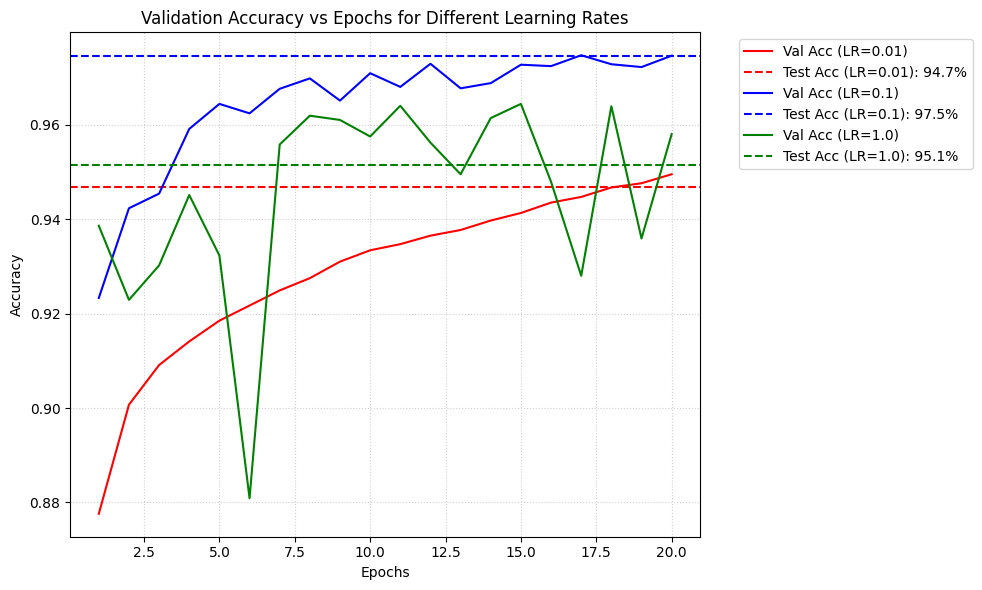

In [14]:
plot_val_accuracy_history(histories, test_accuracies)

# PyTorch 

Congratulations! 🥳🎉 You've just written a neural network in NumPy from scratch and plotted the validation accuracy across multiple epochs and learning rates! Now it's time to **do it all over again** with the help of the PyTorch (usually and subsequently called Torch) framework. Luckily we won't have to write nearly as many components as a part of our set up process, as Torch already has them built in.

**Note:** You can click on most of the code snippets in the text cells of this section. 

In [20]:
import torch
from torch import nn
from torchvision import datasets, transforms

## Defining the computational device

Torch is built to run on the GPU, often a cuda-enabled one from Nvidia, but it can also run on the CPU if a GPU isn't available. In order to take advantage of a GPU, we have to explicitly move our data to it, such as training data, or trainable parameters, in order to properly utilize performance benefits from the GPU. Of course, it's unknown to me if you have a GPU, just like it will be unknown to you if someone who stumbles across your own publicly available Torch code will have a GPU.

Thus we must check to see if a GPU is available and set our `device` appropriately. Further, we will write our torch code with the assumption that there is a GPU available. 

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## Creating the Datasets

To instantiate the MNIST dataset we'll be using a built-in dataset from the [`torchvision`](https://docs.pytorch.org/vision/stable/index.html) library. Luckily this makes things easy for us. **Be aware** that it will download the entirety of the MNIST dataset to the same directory where this notebook resides.

Torch is more of a framework than a library, as it expects that we are trying to complete tasks within the particular domain of developing and evaluating ML models, and implicitly includes a lot of computation and accounting to aid in this task. As such, on a CPU at least, Torch will require more computational time to train and evaluate, compared to NumPy. 

Because of this, we will decrease the size of the dataset, as compared to the NumPy implementation. 

In [22]:
from torch.utils.data import Subset
import numpy as np

transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [0,1] float tensor
    transforms.Normalize((0.1307,), (0.3081,))  # Standard MNIST normalization
])

# Download training and test sets to current directory (i.e., "./")
train_dataset = datasets.MNIST(
    root=".",  # Save data to current directory
    train=True,
    transform=transform,
    download=True
)

train_set_size = len(train_dataset)
indices = torch.arange(train_set_size)
# We'll be using a smaller training set, as noted in the above description
train_idxs = np.random.choice(50000, size=5000, replace=False)
val_idxs = indices[50000:]

val_dataset = Subset(train_dataset, train_idxs)
train_dataset = Subset(train_dataset, train_idxs)

test_dataset = datasets.MNIST(
    root=".",  # Save data to current directory
    train=False,
    transform=transform,
    download=True
)

print("Shape of sample in the torchvision MNIST dataset:", train_dataset[0][0].shape)

100.0%
100.0%
100.0%
100.0%

Shape of sample in the torchvision MNIST dataset: torch.Size([1, 28, 28])


## Building the Model

To build the model we've just built in Numpy, we'll need to use the corresponding components in PyTorch, namely [`Flatten`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Flatten.html), [`Linear`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html), [`ReLU`](https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html), and [`Sequential`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html). 

The  [`Sequential`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html) class is a container in which we will hold and nicely manage all of our layers.  [`Sequential`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html) itself is a subclass of [`Module`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html) which contains more information on the [`Sequential`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html) methods we'll be using in this assignment. 

To make things simple, we'll define a class called `MNISTNet`, make it a subclass of [`Module`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html), and define our neural network in there so it's easier to instantiate a new one whenever we want.

We will only be using this to classify MNIST images, so feel free to hardcode the dimensions into the [`Linear`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html) layers.

Importantly, what is [`Flatten`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Flatten.html)? In the NumPy implementation our samples were represented as a one dimensional array. In the [`torchvision`](https://docs.pytorch.org/vision/stable/index.html) version of the dataset, however, the are three dimensional tensors, as you can see in the output of the above cell. The [`Linear`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html) layer only accepts one dimensional tensors equal to its input size, and as such the input needs to be transformed into one, which is just what [`Flatten`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Flatten.html) does. Essentially, a preprocessing step conveniently baked into our network model.

After defining the network in the `__init__()` method, we will also initialize the network's weights, but the code for that is already written. 

In [23]:
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()

        # --- BUILDING THE MODEL ---
        # input_dim: 28x28 = 784 (MNIST images)
        # hidden_dim: 64 (Previous exercise's shape)
        # output_dim: 10 (Digits 0-9)
        
        self.layers = nn.Sequential(
            nn.Flatten(),               # Transforms (1, 28, 28) tensor to (784,) vector
            nn.Linear(784, 64),         # First Linear layer (Input -> Hidden)
            nn.ReLU(),                  # Activation function
            nn.Linear(64, 10)           # Second Linear layer (Hidden -> Output)
        )

        # Apply the weight initialization provided below
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            # He Initialization (Matches what we did in NumPy)
            nn.init.normal_(m.weight, mean=0.0,
                            std=(2.0 / m.weight.size(1)) ** 0.5)
            nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # --- FORWARD PASS ---
        # Pass the input tensor through the sequential container
        logits = self.layers(x)
        return logits

## Preparation for training

In Torch, in order to use our dataset we have to encase it in a fancy iterator called a [`DataLoader`](https://docs.pytorch.org/docs/stable/data.html). It allows us to set the batch size, shuffle our data (or not), among other things, all of which is useful for training. The [`DataLoader`](https://docs.pytorch.org/docs/stable/data.html) class can be found in `torch.utils.data`. This class will be responsible for serving our mini-batches.

Below do the following:
- Create [`DataLoader`](https://docs.pytorch.org/docs/stable/data.html)s for our train, validation, and test sets. 
  - Set the batch size to 64, as is the case in our NumPy implementation. 
  - Set `shuffle=True` for the training dataloader and `shuffle=False` for the others.

In [24]:
from torch.utils.data import DataLoader

# Instantiate DataLoaders for the training set, validation set, and test set

### Please enter your solution here ###
batch_size = 64

# --- Instantiate DataLoaders ---

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


## Writing the training routine

We'll break the training routine into two parts. In the first part we'll write a function to train for one epoch called `run_epoch`. This can be useful, as we don't have to duplicate code when evaluating our model. In the second part we'll build our training routine across multiple epochs called `train_model`, collecting validation accuracy for each epoch as we go.

```
run_epoch(
    model: nn.Module, 
    dataloader: DataLoader, 
    device: str, 
    loss_fn: Callable[[torch.Tensor, torch.Tensor], torch.Tensor], 
    optimizer = None, 
    is_train: bool = False) -> (float, float):
```

- **Inputs:**
  - `model` -- An instantiated MNISTNet
  - `dataloader` -- A dataloader to iterate over
  - `device` -- A string signifying which device to run calculations on
  - `loss_fn` -- An instantiated loss function
  - `optimizer` -- *Optional:* Only needed when training. Must be included during training.
  - `is_train` -- *Optional:* Set to true when training.

- **Returns:**
  - `avg_loss` -- The model's average loss across all samples in the dataloader.
  - `accuracy` -- The model's accuracy given the samples in the dataloader.



Beyond `DataLoader`s we'll need two other components:

**Loss Function** -- The loss function has the same purpose as in the NumPy implementation. We'll pass this as a passed parameter in both parts.

**Optimizer** -- This is the method we use to update our model weights based on our gradients. Optimizers can be found in [`torch.optim`](https://docs.pytorch.org/docs/stable/optim.html). We will be specifying our learning rate here when instantiating this. We'll instantiate this in the second part, but use it as an argument in the first part.
  - We'll need an optimizer only if we are training. Be sure to make this check. Throw an `RuntimeError` if there is no optimizer but `is_train` is `True`. 

##### Moving to the GPU

All data 

##### Setting the context

**Model** -- Every model has a training and evaluation mode, set by [`model.train()`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.train) and [`model.eval()`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.eval)`. During training individual components of the model might perform calculations, such as collecting statistics on their input, or otherwise behave differently, than when they are only evaluating.

**Autograd** -- One of the benefits of Torch is that it can automatically track and calculate gradient computations. This is great for training, but not needed for evaluation.
  - Autograd is set using a context manager. To track gradients we will put our code in a [`with torch.enable_grad():`](https://docs.pytorch.org/docs/stable/generated/torch.enable_grad.html#enable-grad) block, and [`with torch.no_grad():`](https://docs.pytorch.org/docs/stable/generated/torch.no_grad.html#no-grad).
  - You don't have to call `enable_grad` or `no_grad` in the `with` statement, you can also set it outside, such as `context = torch.enable_grad() if is_train else torch.no_grad()` and set the context using `with context:`. 

##### Training Loop

Next we'll iterate through the dataloader, which returns a tuple at each iteration `(samples, labels)` or `(X, y)`. For every batch we'll want to do the following:
1. *Training only:* Clear all the gradients tracked by the optimizer with [`optimizer.zero_grad()`](https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html#torch.optim.SGD.zero_grad).
2. Run the samples through the model. As good practice, be sure to transfer the samples to `device`, or rather `X.to(device)`. 
3. Calculate the loss.
4. *Training only:* Propagate the loss backwards through the network by calling `loss.backward()`. This will compute the gradients.
5. *Training only:* Step the optimizer, or update all the weights along their gradients, by calling [`optimizer.step()`](https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html#torch.optim.SGD.step)
6. Update the total correct, total number of samples encountered in the epoch thus far, and total loss. 
    - When calculating the total correct and the loss, you'll likely need to use the `argmax()` method, and the `item()` method.

Finally, calculate and return the accuracy and average loss of the epoch.  

In [25]:
def run_epoch(model, dataloader, device, loss_fn, optimizer=None, is_train=False):
    if is_train and optimizer is None:
        raise RuntimeError("Optimizer must be provided when is_train is True.")

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            batch_size = X.size(0)
            if is_train:
                optimizer.zero_grad()

            outputs = model(X)
            loss = loss_fn(outputs, y)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * batch_size
            
            predictions = outputs.argmax(dim=1)
            correct_predictions += (predictions == y).sum().item()
            total_samples += batch_size
            
    avg_loss = total_loss / total_samples
    accuracy = correct_predictions / total_samples

    return avg_loss, accuracy

Second, we'll define our training routine in terms of epochs, collecting the losses and accuracies of the training and validation sets as we go along. Luckily, this is a bit less involved than the previous function.

1. Move the model to the device (yes again, as a part of good practice)
3. Declare and [`SGD`](https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html#sgd) optimizer with the specified learning rate. All other hyperparameters should be zero. You will need to pass the model's parameters, essentially telling the optimizer what it can train, which can be done with the model's `parameters()` method.
4. Iterate through the specified number of epochs, running first on the training set, then on the validation set. Be sure to collect the accuracies and losses along the way. Further, after every epoch, print to the console  the epoch number out of the total number of spcified epochs, the losses of both datasets, and the accuracies of both datasets.
5. Package the losses and accuracies of both data partitions into a dictionary and return this.

The model, as a dynamic object, does not need to be returned. By running the training routine on it, we know that we have modified this object. 

In [29]:
def train(model, train_dataloader, val_dataloader, device, loss_fn, epochs=20, lr=0.1):
    # 1. Move the model to the specified device (CPU, CUDA, or MPS)
    model.to(device)

    # 2. Initialize the SGD optimizer
    # we pass model.parameters() so the optimizer knows which weights to update
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    # Dictionary to store performance metrics for plotting later
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    for epoch in range(epochs):
        # 3. Run training phase
        train_loss, train_acc = run_epoch(
            model, train_dataloader, device, loss_fn, 
            optimizer=optimizer, is_train=True
        )

        # 4. Run validation phase (is_train=False, no optimizer needed)
        val_loss, val_acc = run_epoch(
            model, val_dataloader, device, loss_fn, 
            is_train=False
        )

        # 5. Collect statistics
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # 6. Print progress to console
        print(f"Epoch {epoch + 1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc * 100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}   | Val Acc: {val_acc * 100:.2f}%")
        print("-" * 30)

    return history

## Putting everything together

Like last time, train three models with three different learning rates `0.01`, `0.1`, and `1.0` and plot their validation accuracy and resulting test accuracy. Train each model for `20` epochs. 

Also like last time, if you do this in a loop, which is suggested, be sure to reinstantiate your model every time. 


Training PyTorch Model with Learning Rate: 0.01
Epoch 1/20
Train Loss: 1.4222 | Train Acc: 54.52%
Val Loss: 0.8149   | Val Acc: 77.14%
------------------------------
Epoch 2/20
Train Loss: 0.6857 | Train Acc: 80.44%
Val Loss: 0.5755   | Val Acc: 83.80%
------------------------------
Epoch 3/20
Train Loss: 0.5326 | Train Acc: 84.92%
Val Loss: 0.4801   | Val Acc: 86.22%
------------------------------
Epoch 4/20
Train Loss: 0.4612 | Train Acc: 86.78%
Val Loss: 0.4316   | Val Acc: 87.72%
------------------------------
Epoch 5/20
Train Loss: 0.4173 | Train Acc: 88.18%
Val Loss: 0.4078   | Val Acc: 88.28%
------------------------------
Epoch 6/20
Train Loss: 0.3866 | Train Acc: 88.78%
Val Loss: 0.3792   | Val Acc: 89.00%
------------------------------
Epoch 7/20
Train Loss: 0.3627 | Train Acc: 89.80%
Val Loss: 0.3513   | Val Acc: 90.38%
------------------------------
Epoch 8/20
Train Loss: 0.3428 | Train Acc: 90.44%
Val Loss: 0.3232   | Val Acc: 91.00%
------------------------------
Epoch 9

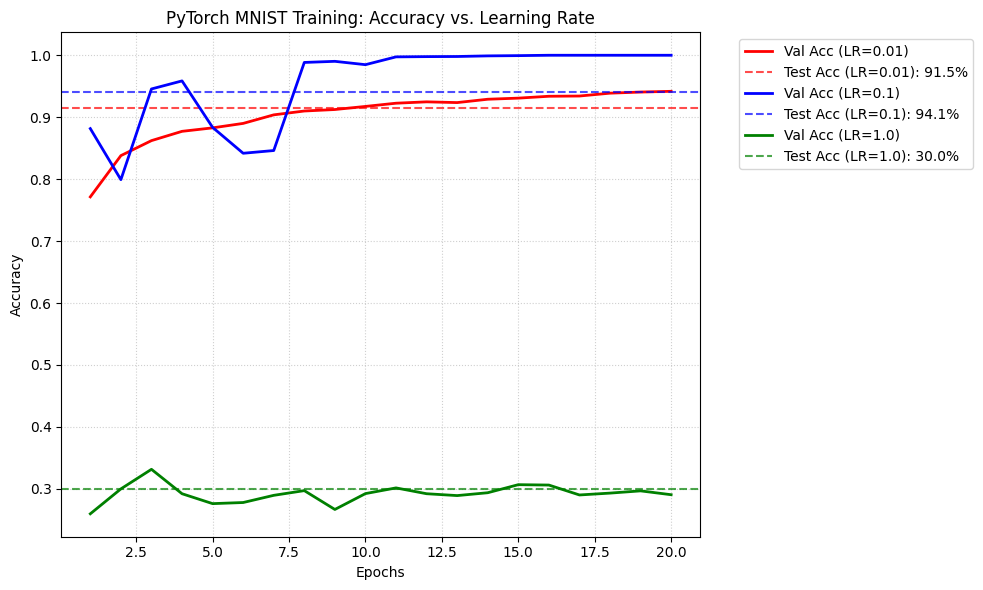

In [30]:

### Please enter your solution here ###

# Parametreler
learning_rates = [0.01, 0.1, 1.0]
epochs = 20
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

histories = []
test_accuracies = []

loss_fn = nn.CrossEntropyLoss()

for lr in learning_rates:
    print(f"\n" + "="*50)
    print(f"Training PyTorch Model with Learning Rate: {lr}")
    print("="*50)

    model = MNISTNet().to(device)

    history = train(
        model=model,
        train_dataloader=train_loader,
        val_dataloader=val_loader,
        device=device,
        loss_fn=loss_fn,
        epochs=epochs,
        lr=lr
    )
    histories.append((lr, history))

    test_loss, test_acc = run_epoch(
        model=model,
        dataloader=test_loader,
        device=device,
        loss_fn=loss_fn,
        is_train=False
    )
    test_accuracies.append(test_acc)
    print(f"Final Test Accuracy for LR {lr}: {test_acc * 100:.2f}%")

plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green']

for i, (lr, history) in enumerate(histories):
    color = colors[i]
    plt.plot(range(1, epochs + 1), history['val_acc'], 
             label=f'Val Acc (LR={lr})', color=color, linewidth=2)
    
    plt.axhline(y=test_accuracies[i], color=color, linestyle='--', alpha=0.7,
                label=f'Test Acc (LR={lr}): {test_accuracies[i]*100:.1f}%')

plt.title('PyTorch MNIST Training: Accuracy vs. Learning Rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()
